<div align="center">
  <img src="fotos/logo_utem.png" alt="Logo UTEM" width="120" style="max-height:140px; height:auto;"/>
  <br><br>
  <p style="margin:2px 0; font-size:16px; font-weight:400;">UNIVERSIDAD TECNOLOGICA METROPOLITANA</p>
  <p style="margin:2px 0; font-size:14px; font-weight:400;">INGENIERIA CIVIL EN CIENCIA DE DATOS</p>
  <p style="margin:2px 0; font-size:14px; font-weight:400;">INFB8090 - COMPUTACION PARALELA Y DISTRIBUIDA</p>
  <br><br>
  <h2 style="margin:0;">LABORATORIO N 4</h2>
  <br>
  <h1 style="margin:0;"><i>Diseño de algoritmos paralelos, descomposición y particionamiento</i></h1>
  <br><br>
  <p style="margin:2px 0;">Profesor: Michael Miranda Sandoval</p>
  <p style="margin:2px 0;">Integrante: Diego Silva Madariaga</p>
  <p style="margin:2px 0;">Fecha: 30 de abril de 2026</p>
</div>

In [8]:
import hashlib
import concurrent.futures
import importlib
import random
import string
import time
import numpy as np
import matplotlib.pyplot as plt
from collections import Counter

### Desafío 1: Analizar estructuralmente un problema antes de paralelizar

1.a) Identificación de descomposición y dependencias

Se deben hacer dos ejercicios prácticos sobre el diseño y estructuración de problemas paralelos, para demostrar cómo la naturaleza de los datos define la estrategia de solución. El objetivo principal es identificar qué partes de un algoritmo pueden ejecutarse simultáneamente y dónde es absolutamente necesaria la coordinación entre los procesos.

- una transformación elemento a elemento sobre un arreglo grande.
- un cálculo agregativo sobre un arreglo, como suma, máximo, promedio o varianza.

Primero se implementa la transformacion elemento a elemento sobre un arreglo grande, aplicado a un escenario generado de ciberseguridad donde se encriptan miles de contraseñas usando el algoritmo de SHA-256. como cada encriptacion es independiente de las demas el arreglo se reparte entre cuatro nucleos y cada uno trabaja sin comunicarse con el resto.

En el patrn Map cada elemento se procesa de forma independiente sin dependencias entre items ni coordinacion durante la fase paralela.

**Pseudocodigo de Hashing de contrasenas con 4 workers con MAP**

```
entrada : lista passwords[0..N-1]  (N = 100000 cadenas de longitud 8)
salida  : lista hashes[0..N-1]

// executor.map asigna cada password a un worker automaticamente
 ProcessPoolExecutor(max_workers=4):
    hashes map(hash_password, passwords)
        // cada tarea: hashes[i] sha256(passwords[i].encode()).hexdigest()
        // sin estado compartido y sin dependencias entre tareas

retornar hashes
```

Tiempo: 97.27s
Total procesado: 100000


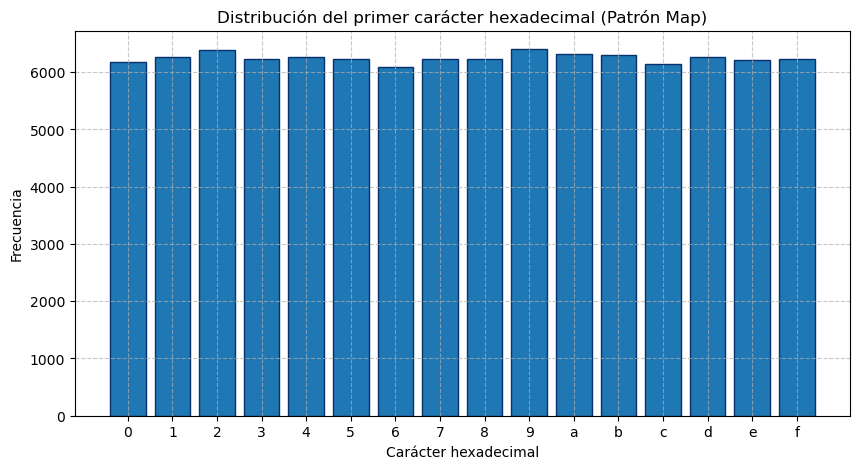

In [9]:
import importlib
import funcion1_tarea4

importlib.reload(funcion1_tarea4)
_ = funcion1_tarea4.run_map_password_hash_demo(num_workers=4)

El segundo codigo implementa un calculo agregativo sobre un arreglo usando datos simulados de videojuegos donde se suman millones de registros de daño. El arreglo se divide en cuatro partes y cada nucleo calcula su suma parcial y al final se combina los subtotales para entregar el total definitivo.

**Pseudocodigo de Suma de daño con patron Reduction**

```
entrada : arreglo damage_logs[0..N-1]  (N = 50000000 enteros int32)
salida  : total_damage (entero)

// Particionamiento uniforme por bloques
chunks[0..3] <- np.array_split(damage_logs, 4)

// MAP paralelo  variable local por worker: suma_parcial
ProcessPoolExecutor(max_workers=4):
    partial_sums[0..3] <- map(np.sum, chunks)
        // worker w: retorna np.sum(chunks[w])  — sin estado compartido

// REDUCE secuencial — suma de sumas parciales
total_damage <- sum(partial_sums)
retornar total_damage
```

Tiempo: 1.22s
Daño Total: 12475778467


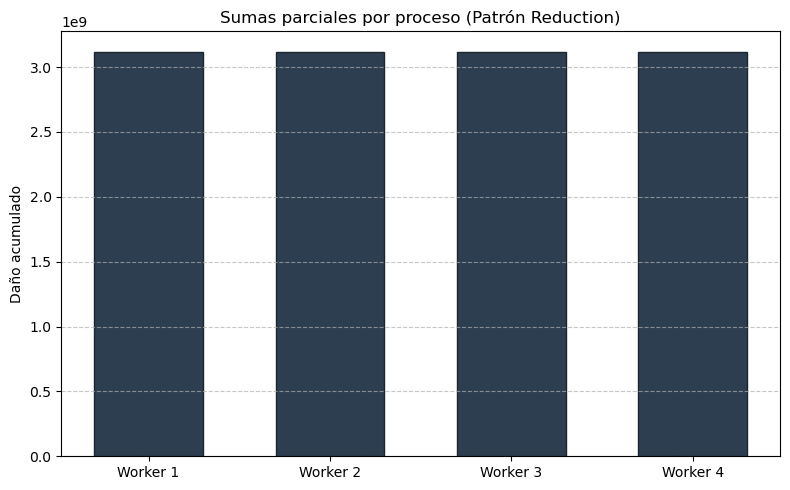

In [10]:
import importlib
import funcion2_tarea4

importlib.reload(funcion2_tarea4)
_ = funcion2_tarea4.run_reduction_damage_demo(num_workers=4)

En el caso de hashing la entrada es un arreglo de contraseñas y la salida es el mismo arreglo con los hashes, aqui conviene una descomposicion por datos por que la operacion sobre cada elemento es independiente, encriptar una contraseña no necesita el resultado de ninguna otra. El arreglo se divide en 4 bloques y cada worker procesa el suyo sin coordinarse. La parte secuencial se limita a leer el arreglo y recolectar los resultados al final.

Para la suma de daño la entrada es un arreglo numerico y la salida es un solo valor. Tambien conviene descomposicion por datos por que el arreglo se divide en 4 chunks y cada worker opera sobre el suyo de forma independiente. pero aqui si hay diferencia por que si hay output-dependencias, pero cada worker calcula su suma parcial de forma local y el proceso principal las combina al final, a fase de agregacion es necesariamente secuencial.

1.b) Comparación entre esquemas de particionamiento

A partir de uno de los problemas analizados en la parte anterior, el grupo debe comparar al menos
tres esquemas de particionamiento entre los siguientes:

- uniforme (por bloques de igual tamaño);
- cíclico;
- adaptado a dominios irregulares.

Se usara el primer problema de hashing de contraseñas de la parte anterior, pero ahora adaptado para comparar tres esquemas de particionamiento por bloques, cíclico y adaptado a dominios irregulares. Se usa una carga de trabajo intencionalmente heterogenea con contraseñas de longitudes muy distintas para que las diferencias de balance entre esquemas sean visibles en los resultados.

**Pseudocodigo Comparacion de esquemas de particionamiento **

```
entrada : lista items[(idx, pwd)]  con contrasenas de longitudes heterogeneas
          P = 4 workers
salida  : hashes, tiempo y desbalance por cada esquema

//Esquema 1: Bloques 
bloques <- []
base, extra <- divmod(N, P)
inicio <- 0
para w desde 0 hasta P-1:
    fin <- inicio + base + (1 si w < extra, si no 0)
    bloques[w] <- items[inicio .. fin-1]    // segmentos contiguos de igual tamano
    inicio <- fin

con ProcessPoolExecutor(P workers):
    resultados <- map(_hash_chunk, bloques)
hashes <- ordenar por indice y concatenar

// Esquema 2: Ciclico 
para i desde 0 hasta P-1:
    chunks_ciclico[i] <- items[i :: P]      // items 0,4,8,... | 1,5,9,... | ...

con ProcessPoolExecutor(P workers):
    resultados <- map(_hash_chunk, chunks_ciclico)
hashes <- ordenar por indice y concatenar

// Esquema 3: Adaptado a dominios irregulares 
items_ord <- ordenar items por len(pwd) de mayor a menor
bins[0..P-1] <- P listas vacias
carga[0..P-1] <- P ceros
para item en items_ord:
    w <- indice del worker con menor carga acumulada
    bins[w].append(item)
    carga[w] += len(item.pwd)    // estimacion del costo de cada tarea

con ProcessPoolExecutor(P workers):
    resultados <- map(_hash_chunk, bins)
hashes <- ordenar por indice y concatenar
```

Comparacion de particionamiento para hashing
workers=4 | passwords=120000
------------------------------------------------------------------------------------------------
esquema        tiempo[s]     speedup    desbalance       total      ok         backend
------------------------------------------------------------------------------------------------
bloques            1.092        1.00         1.005      120000    True       processes
irregular          1.102        0.99         1.000      120000    True       processes
ciclico            1.113        0.98         1.006      120000    True       processes


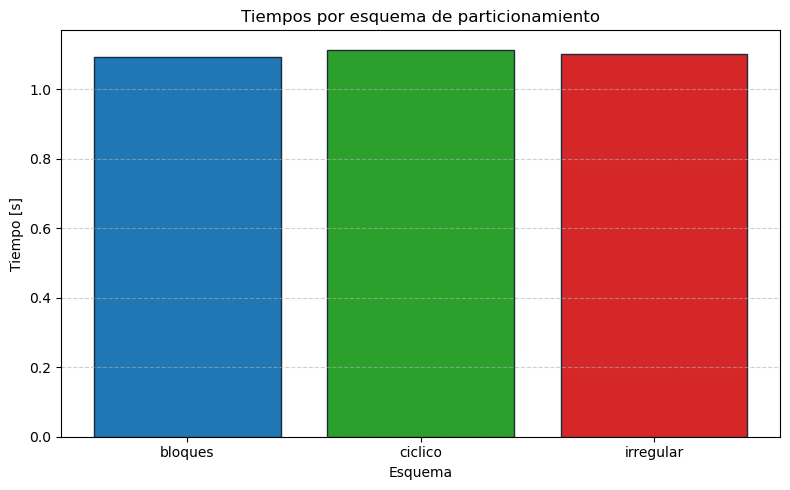

In [11]:
import importlib
import funcion3_tarea4

importlib.reload(funcion3_tarea4)
_ = funcion3_tarea4.run_partitioning_hash_demo(num_workers=4)

El esquema de bloques asigna segmentos contiguos a cada worker lo que favorece el acceso a memoria pero el costo por elemento no es uniforme por lo que un worker concentra el trabajo pesado y se convierte en cuello de botella.

El esquema ciclico reparte los elementos en turno rotativo lo que distribuye mejor la carga cuando los costos son irregulares pero los accesos a memoria no son contiguos.

El esquema adaptado ordena las tareas por costo estimado y las asigna al worker menos cargado logrando el mejor balance. Su desventaja es el overhead del ordenamiento previo.

Los resultados confirman esto por que se ve como el metodo irregular resulto ser el que tuvo menos desbalance, pero el overhead le afecto teniendo un speedup de menos de 1% menor a por bloques

### Desafío 2: Pasar del problema al código paralelo

2.a) Caso de arreglo independiente con reducción
Cada grupo debe diseñar una estrategia paralela para un problema sobre arreglos grandes que incluya:
- procesamiento por particiones o chunks;
- cálculo local por cada worker;
- combinación global mediante una reducción o ensamblaje final

El codigo implementado es un conteo de ocurrencias bajo una condición sobre un arreglo grande, aplicado a datos fictisios de  logs de latencia de servidores. Se analizan 5 millones de tiempos de respuesta para calcular el Percentil 95 y contar cuántas lecturas lo superan. 

El codigo ejecuta primero una version secuencial completa y luego una paralela donde cada worker construye su histograma local los cuales se combinan por reduccion para obtener el resultado global.

**Pseudocodigo  Analisis de latencias**

```
// Secuencial  [run_latency_secuencial]
entrada : arreglo latencias[0..N-1]  (N = 5 000 000 floats en ms)
salida  : p95_ms, n_anomalias

indices     <- clip(latencias.astype(int), 0, 999)
hist_global <- bincount(indices, length=1000)
acumulado <- 0
para b desde 0 hasta 999:
    acumulado += hist_global[b]
    si acumulado >= 0.95 * N:
        p95_ms <- b
        romper
n_anomalias <- sum(hist_global[p95_ms:])
retornar (p95_ms, n_anomalias)

// Paralelo  [run_latency_paralelo]
entrada : latencias[0..N-1], P = 4 workers
salida  : p95_ms, n_anomalias

// Variable local por worker : hist_local  (array de 1000 enteros)
// Variables globales post-reduccion: hist_global, p95_ms, n_anomalias

chunks[0..3] <- np.array_split(latencias, 4)  // bloques uniformes

con ProcessPoolExecutor(max_workers=4):
    hist_locales[0..3] <- map(calcular_histograma_local, chunks)
        // calcular_histograma_local(chunk):
        //   indices <- clip(chunk.astype(int), 0, 999)
        //   retornar bincount(indices, length=1000)

hist_global <- np.sum(hist_locales, axis=0)
p95_ms      <- calcular_p95(hist_global, N)
n_anomalias <- sum(hist_global[p95_ms:])
retornar (p95_ms, n_anomalias)
```

Lecturas totales: 5,000,000

[ SECUENCIAL ]
  Percentil 95 : 219 ms
  Anomalias    : 250,666  (5.0%)
  Tiempo       : 0.028 s

[ PARALELO - 4 workers ]
  Percentil 95 : 219 ms
  Anomalias    : 250,666  (5.0%)
  Tiempo       : 1.054 s

Speedup: 0.03x
Verificacion OK: P95 secuencial == P95 paralelo



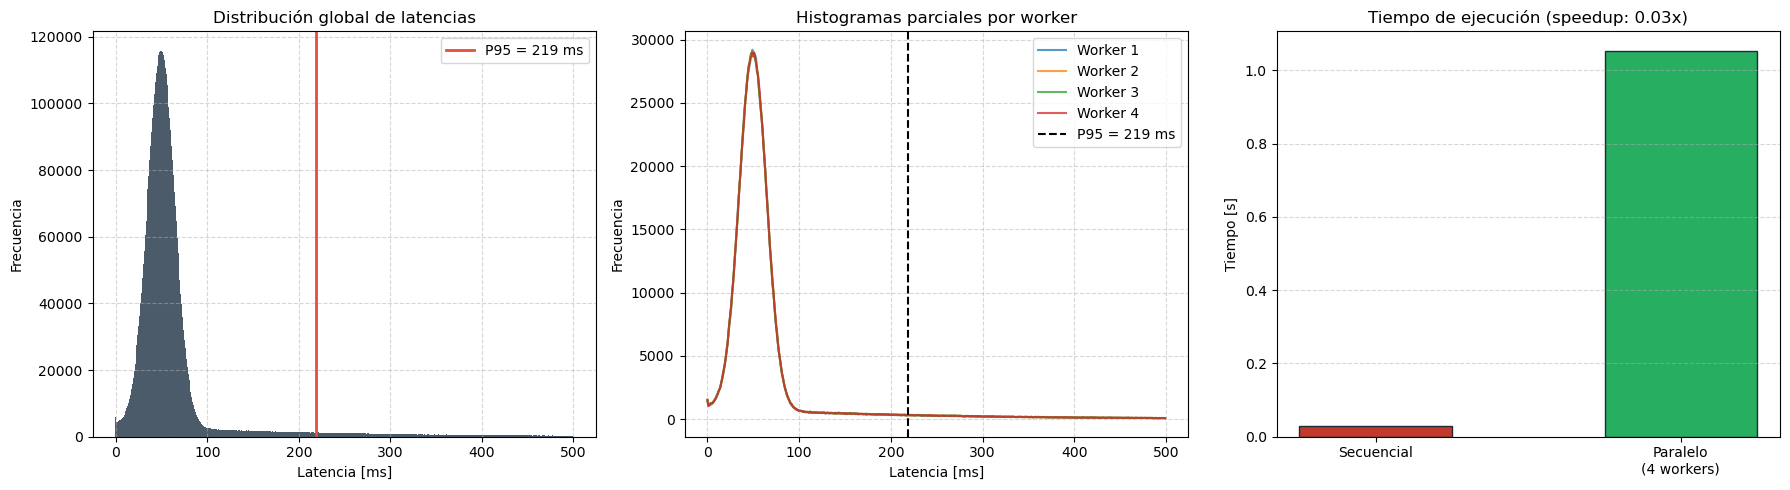

In [12]:
import importlib
import funcion_desafio2a

importlib.reload(funcion_desafio2a)
_ = funcion_desafio2a.run_latency_analysis(num_workers=4)

La entrada es un arreglo de N latencias en ms y la salida son dos valores: el umbral P95 y el conteo de lecturas que lo superan como anomalias. Como mapear cada latencia a un bin es independiente del resto se usa particionamiento uniforme por bloques el costo por elemento es homogeneo asi que el balance es perfecto.

Cada worker tiene como variable local su histograma parcial. Los histograma combinado, P95 y anomalias se calculan solo despues de la reduccion que consiste en sumar los histogramas bin a bin. Esta operacion es asociativa y conmutativa por lo que el resultado es idéntico al secuencial.

El speedup result negativo (0.03x) porque np.bincount es código C optimizado que termina en milisegundos mientras el overhead de crear procesos y serializar los chunks supera ese tiempo lo que demuestra que cuando la tarea por worker es demasiado rapida el paralelismo perjudica en vez de ayudar.

2.b) Caso con dependencia local o frontera

En esta parte, el grupo debe diseñar un caso donde la independencia no sea total. Puede tratarse de:
- stencil unidimensional;
- promedio móvil;
- operación por ventanas sobre un arreglo;

Se implemento una operacion de filtro gaussiano aplicado a 200.000 lecturas de temperatura de sensores IoT por ventanas sobre un arreglo, aqui el output depende de los 2k+1 vecinos centrados en i, lo que impide una partición ingenua, pues los elementos en los bordes de cada bloque necesitan datos del bloque siguiente. La solución es enviar a cada worker su bloque mas k elementos extra de cada lado  resolviendo la dependencia sin comunicacion entre procesos durante la ejecucion.

**Pseudocodigo  Filtro gaussiano con halos**

```
// Secuencial  [_filtro_secuencial]
entrada : senal T[0..N-1]  (N = 200 000 floats), ventana k=15, kernel gaussiano (sigma=2.5)
salida  : senal filtrada F[0..N-1]

T_pad <- pad(T, k, mode='edge')
para i desde 0 hasta N-1:
    F[i] <- dot(kernel, T_pad[i : i + 2k+1])
retornar F

// Paralelo con halos  [run_iot_temperature_filter]
entrada : T[0..N-1], kernel, k=15, P = 4 workers
salida  : F[0..N-1]

T_pad <- pad(T, k, mode='edge')

indices[0..3] <- np.array_split(arange(N), 4)
para w desde 0 hasta 3:
    start <- indices[w][0]
    end   <- indices[w][-1] + 1
    chunk_con_halos <- T_pad[start : end + 2k]   // halo izq. + bloque util + halo der.
    args[w] <- (chunk_con_halos, kernel, k)

con ProcessPoolExecutor(max_workers=4):
    parciales[0..3] <- map(apply_filter_local, args)
        // apply_filter_local(chunk, kernel, k):
        //   n_out <- len(chunk) - 2k
        //   para i desde 0 hasta n_out-1:
        //       F_local[i] <- dot(kernel, chunk[i : i + 2k+1])
        //   retornar F_local   // solo el centro, los halos se descartan

// BARRERA implicita al cerrar el bloque with

F <- concatenar(parciales[0..3])
retornar F
```

[ SECUENCIAL ]
  Tiempo : 0.260 s
[ PARALELO - 4 workers ]
  Tiempo      : 1.046 s
  Speedup     : 0.25x
  Error maximo secuencial vs paralelo: 0.00e+00


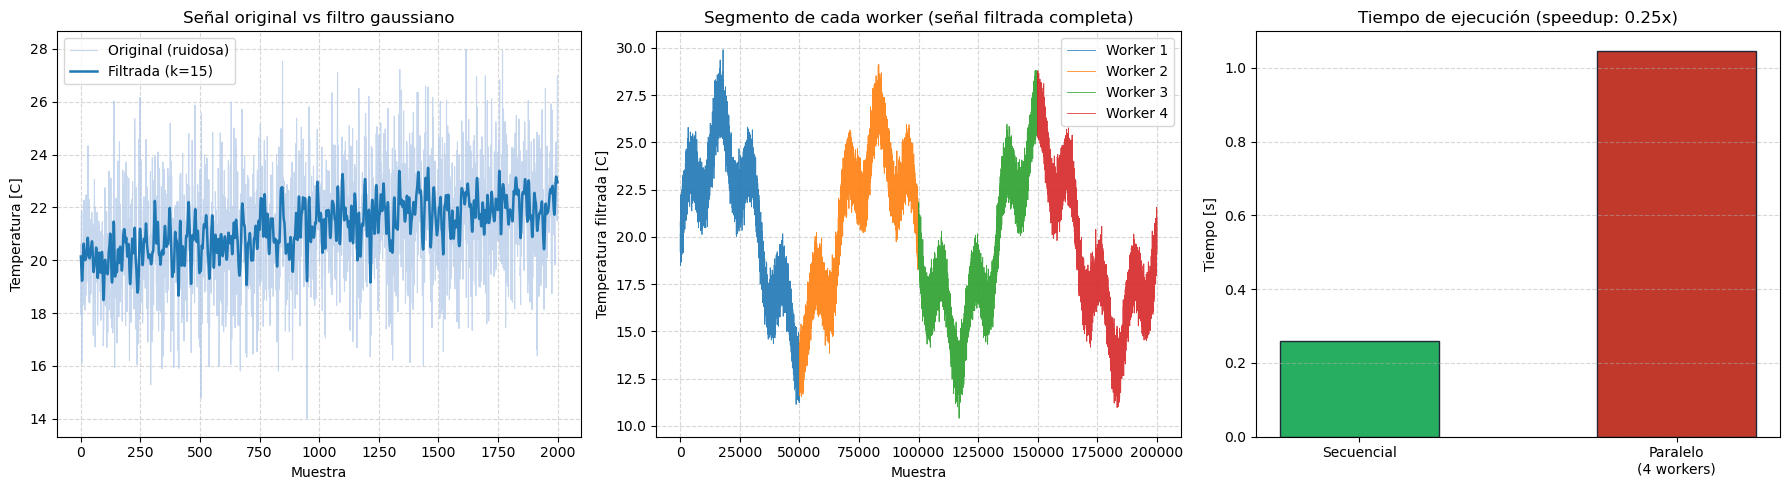

In [13]:
import importlib
import funcion_desafio2b

importlib.reload(funcion_desafio2b)
_ = funcion_desafio2b.run_iot_temperature_filter(num_workers=4)

Al enviar a cada worker a su bloque más k elementos extra a cada lado. El worker procesa el rango completo y devuelve solo los resultados del centro. Con esto la dependencia queda resuelta antes de lanzar los procesos y no se necesita comunicacion entre workers durante la ejecucion.

El error maximo entre la versión secuencial y la paralela es cero confirmando que el mecanismo de halos es matemáticamente equivalente, pero el speedup fue negativo por la misma razon que en el ejercicio anterior ya que el overhead de procesos supera el tiempo de computo para este tamaño de datos, aunque en este caso la diferencia no es tanta por que el bucle usa python en vez de c como el ejercicio anterior, asiendo que tarde mas.

### Desafío 3: Pipeline de análisis de logs HTTP

3.a) Diseño de una estrategia para tareas independientes o pipeline simple.

Opcion de pipeline simple de 3 etapas sobre logs HTTP simulados

Se  van procesar 300.000 lineas de log HTTP generadas. El pipeline tiene tres etapas que son:

- Parseo: cada worker extrae IP, hora, metodo, ruta, estado y tamaño de sus lineas crudas.
- Enriquecimiento: cada worker añade la categoría HTTP (exito / redireccion / error cliente / error servidor) a sus registros.
- Agregacion: cada worker acumula conteos locales por IP, ruta, hora y categoria; el proceso principal los suma (Reduction sobre Counters).

Cada etapa lanza un ProcessPoolExecutor independiente sobre los 4 chunks del lote que al cerrarse el bloque with,todos los workers de esa etapa han terminado y el resultado esta disponible en el proceso principal, eso constituye la barrera entre etapas,las 3 etapas tienen dependencia secuencial entre ellas, la etapa 2 necesita los registros de la etapa 1, y la etapa 3 necesita los de la etapa 2 lo que hace que no haya condicion de carrera. La barrera entre etapas la implementa el cierre del bloque with cuando termina, todos los workers acabaron y el resultado está disponible para la siguiente etapa.

Flujo: lineas crudas -> registros -> registros enriquecidos -> Counters parciales -> global.

**Pseudocodigo de Pipeline HTTP de 3 etapas **

```
entrada : lista L de 300 000 lineas de log HTTP crudas, P = 4 workers
salida  : conteos globales {por_ip, por_ruta, por_hora, por_categoria}

// Particionamiento ciclico
chunks[0..3] <- [L[i::4] para i en 0..3]

// ETAPA 1  Parseo
con ProcessPoolExecutor(max_workers=4):
    registros[0..3] <- map(parsear_lote, chunks)
        // parsear_lote(lineas): aplica regex, extrae ip/hora/metodo/ruta/estado/tamano

// ETAPA 2  Enriquecimiento
con ProcessPoolExecutor(max_workers=4):
    enriquecidos[0..3] <- map(enriquecer_lote, registros)
        // enriquecer_lote(registros): aniade campo categoria segun codigo HTTP

// ETAPA 3  Agregacion local
con ProcessPoolExecutor(max_workers=4):
    parciales[0..3] <- map(agregar_lote, enriquecidos)
        // agregar_lote(registros): Counter local por ip, ruta, hora, categoria

// REDUCE secuencial
global <- {por_ip: Counter(), por_ruta: Counter(), por_hora: Counter(), por_categoria: Counter()}
para cada parcial en parciales[0..3]:
    para cada clave en global:
        global[clave] += parcial[clave]

retornar global
```

Generando 300,000 líneas de log HTTP...
[Etapa 1 - Parseo]      1.559 s  |  300,000 registros
[Etapa 2 - Enriquec.]   1.473 s
[Etapa 3 - Agregación]  1.336 s
Tiempo total pipeline:  4.368 s


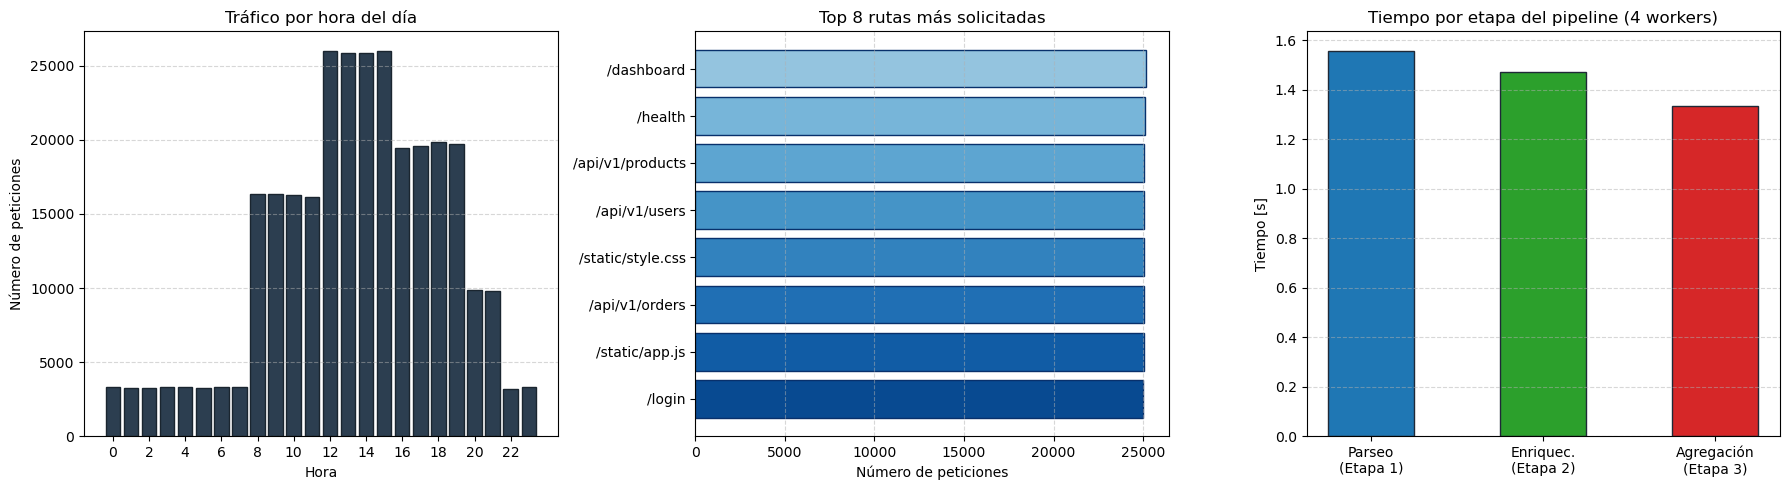

In [14]:
import importlib
import funcion_desafio3

importlib.reload(funcion_desafio3)
_ = funcion_desafio3.run_http_pipeline(num_workers=4)

El balance de carga es uniforme pues el particionamiento ciclico reparte lineas en partes iguales y el costo de parsear una linea es homogeneo sin riesgo de que un worker se retrase.

El principal overhead es la serializacion entre etapas pues cada cierre de executor serializa los resultados antes de pasarlos a la siguiente etapa. La etapa 1 transfiere el mayor volumen y la etapa 3 el menor. En total hay 3 rondas de serializacion, una por etapa.

Las 3 etapas tardan similar, ~1.5s cada una porque el costo dominante es la serializacion entre barreras, no el computo en si,en total ~4.5s repartidos en las 3 etapas del pipeline.

3.b) Justificación técnica final del diseño

A partir del conjunto completo del laboratorio, cada grupo debe redactar una justificación final que responda a la siguiente pregunta: Dado un problema nuevo sobre arreglos o tareas independientes, ¿qué criterios utilizaría el grupo para decidir cómo descomponerlo, cómo particionarlo y qué puntos de coordinación deberían explicitarse antes de implementarlo?

Cuando un problema es sobre arreglos o tareas independientes el primer criterio es ver la naturaleza de los datos y ver si cada elemento puede procesarse de forma aislada o depende de sus vecinos. Cuando no hay dependencias conviene descomposicion por datos con patron Map y una reducción final. Cuando si hay dependencias como en el filtro gaussiano se debe resolver la dependencia con halos antes de lanzar los procesos para evitar resultados incorrectos.

Tambien hay que ver la regularidad de la carga pues si el costo por elemento es homogeneo el particionamiento por bloques da buen balance y localidad de cache. Si es irregular como contraseñas de longitudes distintas el esquema de bloques genera desbalance y algun worker hace cuello de botella, ahi el esquema ciclico reparte mejor la carga y el adaptado la minimiza asignando primero las tareas mas pesadas al worker menos cargado. Esto es importante por que el desbalance desperdicia cores disponibles.

El tercer criterio es la granularidad pues en este lab y el anterior se observo que el overhead de ProcessPoolExecutor puede superar el trabajo util cuando la tarea por worker es pequeña y produce speedup menor que 1. por lo que antes de implementar hay que estimar si el tiempo de computo por chunk justifica el costo de crear procesos y serializar datos. 

Si el trabajo ya esta optimizado en C  como el np.bincount paralelizar en Python es contraproducente pero si es bucle Python puro con un gran volumen el paralelismo si puede aportar ganancias reales.

El cuarto y ultimo criterio es la coordinacion explicita pues si el resultado depende de todos los otros resultados parciales la reduccion debe hacerse sobre variables locales por worker para evitar condiciones de carrera. En un pipeline cada barrera entre etapas debe estar definida antes de codificar junto con el tipo de dato que fluye de una etapa a la siguiente, porque cada cierre de executor introduce costo de serialización adicional.

<div align="center">
  <p style="font-size:11px; color:#8a8a8a; margin:6px 0 0 0;">
    Equipo utilizado: AMD Ryzen 7 5700X | 16 GB RAM | NVIDIA GeForce RTX 4060
  </p>
</div>